In [1]:
import pandas as pd
from sqlalchemy import create_engine, text

# ------------------------------------
# CONFIG: MySQL connection settings
# ------------------------------------
MYSQL_USER = "churn_user"
MYSQL_PASSWORD = "your_password_here"
MYSQL_HOST = "localhost"
MYSQL_PORT = 3306
MYSQL_DB = "churn_db"

CSV_PATH = "../data/telco_churn.csv"   # because notebook sits inside /notebooks folder

# ------------------------------------
# 1. Load CSV
# ------------------------------------
df = pd.read_csv(CSV_PATH)
print("Loaded CSV shape:", df.shape)
print("Columns:", df.columns.tolist())

# Clean column names
df.columns = [col.strip() for col in df.columns]

# Clean string fields
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# ------------------------------------
# 2. Connect to MySQL
# ------------------------------------
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}"
)

# ------------------------------------
# 3. Write DataFrame → MySQL
# ------------------------------------
df.to_sql("raw_telco", con=engine, if_exists="replace", index=False)
print("Loaded into MySQL → churn_db.raw_telco")

# ------------------------------------
# 4. Simple verification queries
# ------------------------------------
with engine.connect() as conn:
    total_rows = conn.execute(text("SELECT COUNT(*) FROM raw_telco")).scalar()
    unique_customers = conn.execute(text("SELECT COUNT(DISTINCT customerID) FROM raw_telco")).scalar()
    churn_rate = conn.execute(text("""
        SELECT SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*)
        FROM raw_telco;
    """)).scalar()

print("Total rows:", total_rows)
print("Unique customers:", unique_customers)
print("Churn rate:", churn_rate)


Loaded CSV shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Loaded into MySQL → churn_db.raw_telco
Total rows: 7043
Unique customers: 7043
Churn rate: 0.2654


Loaded rows: (7043, 27)

Target distribution (proportion):
Churn_Flag
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Service feature summary:
                         count      mean       std  min  25%  50%  75%  max
total_services          7043.0  2.037910  1.847682  0.0  0.0  2.0  3.0  6.0
support_services_count  7043.0  1.265654  1.286879  0.0  0.0  1.0  2.0  4.0
num_streaming           7043.0  0.772256  0.852573  0.0  0.0  0.0  2.0  2.0

Train / Test sizes: (5282, 10) (1761, 10)

Logistic Regression metrics:
Accuracy: 0.791, Precision: 0.629, Recall: 0.516, AUC: 0.836
Confusion matrix (LR):
[[1152  142]
 [ 226  241]]

Logistic Regression Coefficients (sorted by absolute magnitude):
               feature      coef
                tenure -1.052601
        MonthlyCharges  0.823912
          TotalCharges  0.371168
         SeniorCitizen  0.347754
support_services_count -0.344232
          autopay_flag -0.306907
        total_services -0.163709
         num_streaming  0.1

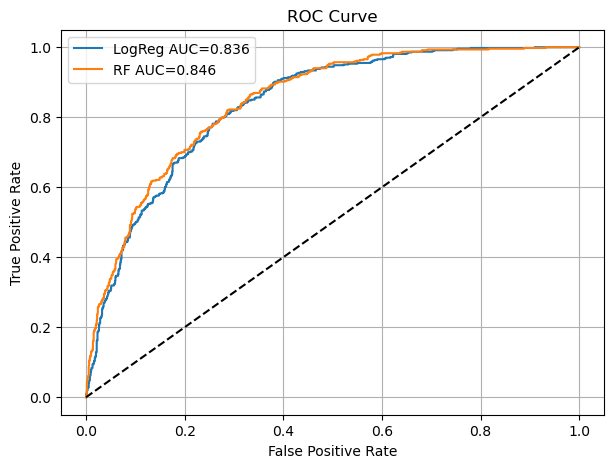


Saved models to output/*.joblib
Saved predictions to output/predictions_for_powerbi.csv

Summary metrics (for notes):
{'LR': {'accuracy': 0.7910278250993753, 'precision': 0.6292428198433421, 'recall': 0.5160599571734475, 'auc': 0.8364457602044024}, 'RF': {'accuracy': 0.7921635434412265, 'precision': 0.6747404844290658, 'recall': 0.41755888650963596, 'auc': 0.8456059758595924}}


In [1]:
# Full modelling pipeline: load from MySQL -> train LR & RF -> evaluate -> save models & predictions
# Run this in the churn-env conda environment in Jupyter.

# ------------------------------
# 0. Imports
# ------------------------------
import os
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ------------------------------
# 1. Config / DB connection
# ------------------------------
MYSQL_USER = "churn_user"
MYSQL_PASSWORD = "your_password_here"
MYSQL_HOST = "localhost"
MYSQL_PORT = 3306
MYSQL_DB = "churn_db"

engine = create_engine(f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}")

# Ensure output directory exists
os.makedirs("output", exist_ok=True)

# ------------------------------
# 2. Load modelling table from MySQL
# ------------------------------
sql = "SELECT * FROM clean_telco_v3;"
df = pd.read_sql(sql, engine)
print(f"Loaded rows: {df.shape}")

# ------------------------------
# 3. Quick checks / target balance
# ------------------------------
print("\nTarget distribution (proportion):")
print(df['Churn_Flag'].value_counts(normalize=True))

print("\nService feature summary:")
print(df[['total_services','support_services_count','num_streaming']].describe().T)

# ------------------------------
# 4. Feature selection & prepare dataset
# ------------------------------
# We'll keep customerID to reconnect predictions later.
features = [
    'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
    'contract_months', 'autopay_flag', 'total_services',
    'support_services_count', 'num_streaming', 'multiple_lines_flag'
]

# Defensive: ensure features exist
missing = [f for f in features if f not in df.columns]
if missing:
    raise SystemExit(f"Missing expected features in dataset: {missing}")

# Drop rows missing target (should not exist, but safe)
df = df.dropna(subset=['Churn_Flag'])

# If TotalCharges NULLs still exist, impute a reasonable fallback: MonthlyCharges * tenure
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])

# Build X, but keep customerID alongside for later merging
X = df[features].copy()
X['customerID'] = df['customerID'].values  # keep as column
y = df['Churn_Flag'].astype(int).values

# ------------------------------
# 5. Train/test split (preserve customerID in test set)
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Separate customerID column out of feature matrices
train_customer_ids = X_train['customerID'].values
test_customer_ids  = X_test['customerID'].values
X_train = X_train.drop(columns=['customerID'])
X_test  = X_test.drop(columns=['customerID'])

print("\nTrain / Test sizes:", X_train.shape, X_test.shape)

# ------------------------------
# 6. Scaling numeric features for Logistic Regression
# ------------------------------
num_cols = ['tenure','MonthlyCharges','TotalCharges','total_services','support_services_count','num_streaming']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# Fit scaler on training numeric columns
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

# ------------------------------
# 7. Logistic Regression (baseline, interpretable)
# ------------------------------
logreg = LogisticRegression(max_iter=2000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_lr  = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:,1]

# LR metrics
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr  = recall_score(y_test, y_pred_lr, zero_division=0)
auc_lr  = roc_auc_score(y_test, y_proba_lr)

print("\nLogistic Regression metrics:")
print(f"Accuracy: {acc_lr:.3f}, Precision: {prec_lr:.3f}, Recall: {rec_lr:.3f}, AUC: {auc_lr:.3f}")
print("Confusion matrix (LR):")
print(confusion_matrix(y_test, y_pred_lr))

# Sorted LR coefficients by absolute value for interpretability
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coef': logreg.coef_[0]
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)
print("\nLogistic Regression Coefficients (sorted by absolute magnitude):")
print(coef_df[['feature','coef']].to_string(index=False))

# ------------------------------
# 8. Random Forest (stronger, non-linear)
# ------------------------------
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

# RF metrics
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, zero_division=0)
auc_rf  = roc_auc_score(y_test, y_proba_rf)

print("\nRandom Forest metrics:")
print(f"Accuracy: {acc_rf:.3f}, Precision: {prec_rf:.3f}, Recall: {rec_rf:.3f}, AUC: {auc_rf:.3f}")
print("Confusion matrix (RF):")
print(confusion_matrix(y_test, y_pred_rf))

# Feature importances from RF
fi = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)
print("\nRandom Forest feature importances:")
print(fi.to_string(index=False))

# ------------------------------
# 9. ROC curve plot (LR vs RF)
# ------------------------------
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label=f'LogReg AUC={auc_lr:.3f}')
plt.plot(fpr_rf, tpr_rf, label=f'RF AUC={auc_rf:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------
# 10. Save models & scaler
# ------------------------------
joblib.dump(logreg, 'output/logreg_model.joblib')
joblib.dump(rf, 'output/rf_model.joblib')
joblib.dump(scaler, 'output/scaler.joblib')
print("\nSaved models to output/*.joblib")

# ------------------------------
# 11. Prepare predictions CSV for Power BI (with customerID)
# ------------------------------
preds = X_test.copy()
preds['customerID'] = test_customer_ids
preds['y_true'] = y_test
preds['y_pred_rf'] = y_pred_rf
preds['y_proba_rf'] = y_proba_rf
preds['y_pred_lr'] = y_pred_lr
preds['y_proba_lr'] = y_proba_lr

# Add a risk_decile column (1 = highest risk)
preds['risk_decile'] = pd.qcut(preds['y_proba_rf'], 10, labels=False, duplicates='drop')
# convert so that 9 => highest; if qcut labels 0.. then invert
if preds['risk_decile'].max() == 9:
    preds['risk_decile'] = 9 - preds['risk_decile']

preds.to_csv('output/predictions_for_powerbi.csv', index=False)
print("Saved predictions to output/predictions_for_powerbi.csv")

# ------------------------------
# 12. Quick summary output for copy-paste into notes
# ------------------------------
summary = {
    'LR': {'accuracy': acc_lr, 'precision': prec_lr, 'recall': rec_lr, 'auc': auc_lr},
    'RF': {'accuracy': acc_rf, 'precision': prec_rf, 'recall': rec_rf, 'auc': auc_rf}
}
print("\nSummary metrics (for notes):")
print(summary)
